<a href="https://colab.research.google.com/github/con123-gif/URT-Enhanced-v2.0/blob/main/Untitled144.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
```python
import numpy as np
from numpy.fft import fft2, ifft2, fftfreq
from scipy.linalg import eigh, svd
import matplotlib.pyplot as plt

phi = (1 + np.sqrt(5)) / 2
delta_star = (80/81) * np.pi / (13 * phi)
print(f'delta_star = {delta_star:.6f}')
print(f'phi = {phi:.6f}')

# ============================================================
# 1. CENTERED ICOSAHEDRON: 13-node adjacency spectrum
# ============================================================
verts = []
for s1 in [1, -1]:
    for s2 in [1, -1]:
        verts.append([0, s1, s2*phi])
        verts.append([s1, s2*phi, 0])
        verts.append([s2*phi, 0, s1])
verts = np.array(verts)

A13 = np.zeros((13, 13))
dists = np.sqrt(((verts[:,None] - verts[None,:])**2).sum(axis=2))
edge_len = np.sort(np.unique(np.round(dists, 8)))[1]
for i in range(12):
    for j in range(i+1, 12):
        if abs(dists[i,j] - edge_len) < 1e-6:
            A13[i,j] = A13[j,i] = 1
for i in range(12):
    A13[i,12] = A13[12,i] = 1

evals, evecs = eigh(A13)
idx = np.argsort(evals)[::-1]
evals = evals[idx]
evecs = evecs[:, idx]

print('Centered icosahedron adjacency eigenvalues:')
n_pos, n_neg = 0, 0
for i, lam in enumerate(evals):
    sign = '+' if lam > 0.001 else ('-' if lam < -0.001 else '0')
    if lam > 0.001: n_pos += 1
    elif lam < -0.001: n_neg += 1
    print(f'  [{sign}] lambda_{i+1} = {lam:+.4f}')
print(f'\nSplit: {n_pos} positive + {n_neg} negative = {n_pos}+{n_neg} = 13')
print(f'4/13 = {4/13:.4f} ~ Omega_m,  9/13 = {9/13:.4f} ~ Omega_Lambda')

# ============================================================
# 2. FOURIER SHELL BASIS
# ============================================================
N = 256
L = 2 * np.pi
kx = fftfreq(N, d=1.0/N)
ky = fftfreq(N, d=1.0/N)
KX, KY = np.meshgrid(kx, ky)
K2 = KX**2 + KY**2
K_mag = np.sqrt(K2)
K2_safe = K2.copy(); K2_safe[0,0] = 1

n_cath = 13
shell_masks = []
for s in range(n_cath):
    mask = (K_mag >= s + 0.5) & (K_mag < s + 1.5)
    shell_masks.append(mask)
    print(f'Shell k={s+1}: {mask.sum()} Fourier modes')

# ============================================================
# 3. HIGH-Re DNS
# ============================================================
nu_mol = 5e-5
dt = 1e-4
n_spinup = 5000
n_sample = 2000
sample_every = 10

np.random.seed(99)
f_hat = np.zeros((N,N), dtype=complex)
for i in range(N):
    for j in range(N):
        km = np.sqrt(kx[i]**2 + ky[j]**2)
        if 3.5 < km < 4.5:
            f_hat[i,j] = 50.0 * np.exp(1j * np.random.uniform(0, 2*np.pi))

np.random.seed(42)
omega_hat = np.zeros((N,N), dtype=complex)
for i in range(N):
    for j in range(N):
        km = np.sqrt(kx[i]**2 + ky[j]**2)
        if 1 <= km <= 60:
            omega_hat[i,j] = 10 * (np.random.randn() + 1j*np.random.randn()) / (1 + km**(5/3))
omega_hat[0,0] = 0

def step_ns(wh, dt, nu, f_hat):
    ph = wh / K2_safe; ph[0,0] = 0
    u = np.real(ifft2(1j * KY * ph))
    v = np.real(ifft2(-1j * KX * ph))
    dwdx = np.real(ifft2(1j * KX * wh))
    dwdy = np.real(ifft2(1j * KY * wh))
    nl1 = fft2(u * dwdx + v * dwdy)
    wh1 = (wh + dt * (-nl1 + f_hat)) / (1 + dt * nu * K2)
    ph1 = wh1 / K2_safe; ph1[0,0] = 0
    u1 = np.real(ifft2(1j * KY * ph1))
    v1 = np.real(ifft2(-1j * KX * ph1))
    dwdx1 = np.real(ifft2(1j * KX * wh1))
    dwdy1 = np.real(ifft2(1j * KY * wh1))
    nl2 = fft2(u1 * dwdx1 + v1 * dwdy1)
    return (wh + dt * (-(nl1+nl2)/2 + f_hat)) / (1 + dt * nu * K2)

print('\nSpinning up DNS...')
for step in range(n_spinup):
    omega_hat = step_ns(omega_hat, dt, nu_mol, f_hat)
    if step % 1000 == 0:
        E = 0.5 * np.sum(np.abs(omega_hat)**2 / K2_safe) / N**4
        print(f'  step {step}: E = {E:.4e}')

print('Collecting snapshots...')
snapshots_hat = []
shell_energies = []

for step in range(n_sample * sample_every):
    omega_hat = step_ns(omega_hat, dt, nu_mol, f_hat)
    if step % sample_every == 0:
        snapshots_hat.append(omega_hat.copy())
        Ek = 0.5 * np.abs(omega_hat)**2 / K2_safe
        Es = np.array([Ek[m].sum() for m in shell_masks])
        shell_energies.append(Es)

shell_energies = np.array(shell_energies)
E_mean = shell_energies.mean(axis=0)
print(f'Collected {len(snapshots_hat)} snapshots')
for s in range(n_cath):
    print(f'  k={s+1:2d}: <E> = {E_mean[s]:.4e}')

# ============================================================
# 4. PROJECTION: CATHEDRAL vs RANDOM vs POD
# ============================================================
def shell_coefficients(omega_hat, shell_masks):
    return np.array([np.sqrt(np.sum(np.abs(omega_hat[m])**2)) for m in shell_masks])

def project_cathedral(omega_hat, evecs, shell_masks):
    a = shell_coefficients(omega_hat, shell_masks)
    c = evecs.T @ a
    a_recon = evecs @ c
    frac = np.sum(a_recon**2) / (np.sum(a**2) + 1e-30)
    return frac, c

def project_random_basis(omega_hat, shell_masks, n_modes=13, n_trials=50):
    a = shell_coefficients(omega_hat, shell_masks)
    fracs = []
    for _ in range(n_trials):
        Q, _ = np.linalg.qr(np.random.randn(13, n_modes))
        c = Q.T @ a
        a_r = Q @ c
        fracs.append(np.sum(a_r**2) / (np.sum(a**2) + 1e-30))
    return np.mean(fracs), np.std(fracs)

cath_fracs = []
rand_fracs_mean = []
rand_fracs_std = []
A_matrix = []

print('\nComputing projections...')
for i, wh in enumerate(snapshots_hat):
    a = shell_coefficients(wh, shell_masks)
    A_matrix.append(a)
    cf, _ = project_cathedral(wh, evecs, shell_masks)
    cath_fracs.append(cf)
    if i % 200 == 0:
        rm, rs = project_random_basis(wh, shell_masks)
        rand_fracs_mean.append(rm)
        rand_fracs_std.append(rs)
    if i % 500 == 0:
        print(f'  snapshot {i}: Cathedral captures {cf:.4f}')

A_matrix = np.array(A_matrix)
U, S, Vt = svd(A_matrix, full_matrices=False)
S2 = S**2
pod_cumulative = np.cumsum(S2) / np.sum(S2)
cath_mean = np.mean(cath_fracs)

print(f'\n{"="*60}')
print(f'RESULTS')
print(f'{"="*60}')
print(f'Cathedral basis: captures {cath_mean:.4f} of shell energy')
print(f'Random 13-mode basis: captures {np.mean(rand_fracs_mean):.4f} +/- {np.mean(rand_fracs_std):.4f}')
print(f'Ratio Cathedral/Random: {cath_mean / np.mean(rand_fracs_mean):.2f}x')
print(f'\nPOD cumulative energy:')
for m in [1, 2, 3, 4, 5, 9, 13]:
    if m <= len(pod_cumulative):
        print(f'  {m:2d} POD modes: {pod_cumulative[m-1]:.4f}')
for m in range(len(pod_cumulative)):
    if pod_cumulative[m] >= cath_mean:
        print(f'\nPOD needs {m+1} modes to match Cathedral')
        break

# ============================================================
# 5. PLOTS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0,0]
k_vals = np.arange(1, n_cath+1)
ax.semilogy(k_vals, E_mean, 'ko-', ms=6, label='DNS mean E(k)')
k41 = E_mean[3] * (k_vals/4)**(-5/3)
ax.semilogy(k_vals, k41, 'r--', alpha=0.5, label=r'$k^{-5/3}$ (K41)')
ax.set_xlabel('Shell k'); ax.set_ylabel('E(k)')
ax.set_title('Mean energy spectrum (shells 1-13)')
ax.legend(); ax.set_xticks(k_vals)

ax = axes[0,1]
ax.plot(cath_fracs, 'b-', alpha=0.5, lw=0.5)
ax.axhline(cath_mean, color='b', ls='--', label=f'Cathedral mean = {cath_mean:.3f}')
ax.axhline(np.mean(rand_fracs_mean), color='r', ls='--', label=f'Random mean = {np.mean(rand_fracs_mean):.3f}')
ax.set_xlabel('Snapshot'); ax.set_ylabel('Energy fraction captured')
ax.set_title('Cathedral vs random projection')
ax.legend(); ax.set_ylim(0, 1.05)

ax = axes[1,0]
ax.bar(range(1, len(S)+1), S2/S2.sum(), color='gray', alpha=0.7)
ax.set_xlabel('POD mode'); ax.set_ylabel('Fractional energy')
ax.set_title('POD mode energy distribution')
ax.set_xticks(range(1, len(S)+1))

ax = axes[1,1]
E_coherent = shell_energies[:, :4].sum(axis=1)
E_exhaust = shell_energies[:, 4:].sum(axis=1)
E_tot = E_coherent + E_exhaust
ax.plot(E_coherent/E_tot, 'b-', alpha=0.5, lw=0.5, label='Coherent (shells 1-4)')
ax.plot(E_exhaust/E_tot, 'r-', alpha=0.5, lw=0.5, label='Exhaust (shells 5-13)')
ax.axhline(4/13, color='b', ls='--', alpha=0.5, label=f'4/13 = {4/13:.3f}')
ax.axhline(9/13, color='r', ls='--', alpha=0.5, label=f'9/13 = {9/13:.3f}')
ax.set_xlabel('Snapshot'); ax.set_ylabel('Energy fraction')
ax.set_title('4+9 energy split (Cathedral prediction)')
ax.legend(fontsize=8); ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('cathedral_13_galerkin.png', dpi=150)
plt.show()

# ============================================================
# 6. GALERKIN ROM: 13-mode Cathedral dynamics
# ============================================================
def build_triad_tensor(n_shells, kn):
    T = np.zeros((n_shells, n_shells, n_shells))
    for n in range(n_shells):
        for p in range(n_shells):
            for q in range(n_shells):
                if abs(kn[p] - kn[q]) <= kn[n] <= kn[p] + kn[q]:
                    T[n,p,q] = np.sqrt(kn[n] * kn[p] * kn[q])
    T_anti = np.zeros_like(T)
    for n in range(n_shells):
        for p in range(n_shells):
            for q in range(n_shells):
                T_anti[n,p,q] = (T[n,p,q] - T[p,n,q]) / 2
    return T_anti

kn = np.arange(1, n_cath + 1, dtype=float)
T = build_triad_tensor(n_cath, kn)
T_cath = np.einsum('nm,pp2,qq2,npq->mp2q2', evecs, evecs, evecs, T)
print(f'\nTriad tensor built: shape = {T_cath.shape}')
print(f'Nonzero elements: {np.count_nonzero(np.abs(T_cath) > 1e-10)}')

f_shell = np.zeros(n_cath)
f_shell[3] = 1.0
f_cath = evecs.T @ f_shell

def galerkin_rhs(a, T, nu, kn, f, evecs):
    a_shell = evecs @ a
    nl = np.einsum('mpq,p,q->m', T, a, a)
    diss_shell = -nu * kn**2 * a_shell
    diss_cath = evecs.T @ diss_shell
    return nl + diss_cath + f

dt_rom = 1e-3
n_rom = 50000
n_trans_rom = 10000
a = np.random.randn(n_cath) * 0.1
a_series = []

print('Running 13-mode Galerkin ROM...')
for step in range(n_rom):
    k1 = galerkin_rhs(a, T_cath, nu_mol, kn, f_cath, evecs)
    k2 = galerkin_rhs(a + dt_rom/2*k1, T_cath, nu_mol, kn, f_cath, evecs)
    k3 = galerkin_rhs(a + dt_rom/2*k2, T_cath, nu_mol, kn, f_cath, evecs)
    k4 = galerkin_rhs(a + dt_rom*k3, T_cath, nu_mol, kn, f_cath, evecs)
    a += dt_rom/6 * (k1 + 2*k2 + 2*k3 + k4)
    if step >= n_trans_rom:
        a_series.append(a.copy())
    if step % 10000 == 0:
        print(f'  step {step}: E = {0.5*np.sum(a**2):.4e}')

a_series = np.array(a_series)
a_shell_series = np.array([evecs @ a_t for a_t in a_series])
E_shell_rom = 0.5 * a_shell_series**2
E_mean_rom = E_shell_rom.mean(axis=0)

print(f'\nROM mean energy per shell:')
for s in range(n_cath):
    ratio = E_mean_rom[s] / (E_mean[s] + 1e-30)
    print(f'  k={s+1:2d}: ROM={E_mean_rom[s]:.4e}, DNS={E_mean[s]:.4e}, ratio={ratio:.2f}')

# ============================================================
# 7. FINAL COMPARISON PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(kn, E_mean, 'ko-', ms=8, label='DNS (full)', zorder=3)
ax.semilogy(kn, E_mean_rom, 'rs--', ms=6, label='13-mode Cathedral ROM')
k41 = E_mean[3] * (kn/4)**(-5/3)
ax.semilogy(kn, k41, 'g:', alpha=0.4, label=r'$k^{-5/3}$')
ax.set_xlabel('Shell k', fontsize=12); ax.set_ylabel('E(k)', fontsize=12)
ax.set_title('Energy spectrum: DNS vs 13-mode Cathedral ROM', fontsize=13)
ax.legend(fontsize=10); ax.set_xticks(kn.astype(int))

ax = axes[1]
E_c_rom = E_shell_rom[:, :4].sum(axis=1)
E_e_rom = E_shell_rom[:, 4:].sum(axis=1)
E_t_rom = E_c_rom + E_e_rom
ax.plot(E_c_rom/(E_t_rom+1e-30), 'b-', alpha=0.3, lw=0.5)
ax.axhline(4/13, color='b', ls='--', lw=2, label=f'4/13 = {4/13:.3f} (Cathedral)')
ax.axhline(np.mean(E_c_rom/(E_t_rom+1e-30)), color='b', ls='-', lw=2,
           label=f'ROM mean = {np.mean(E_c_rom/(E_t_rom+1e-30)):.3f}')
ax.set_xlabel('ROM timestep', fontsize=12)
ax.set_ylabel('Coherent energy fraction', fontsize=12)
ax.set_title('4/13 energy split in Cathedral ROM', fontsize=13)
ax.legend(fontsize=10); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('cathedral_galerkin_comparison.png', dpi=150)
plt.show()

print('\n' + '='*60)
print('SUMMARY')
print('='*60)
print(f'Icosahedral split: {n_pos}+{n_neg} = 13 (exact)')
print(f'Cathedral energy capture: {cath_mean:.4f}')
print(f'Random baseline: {np.mean(rand_fracs_mean):.4f}')
print(f'Ratio: {cath_mean/np.mean(rand_fracs_mean):.2f}x')
```

SyntaxError: invalid syntax (195413537.py, line 1)

In [ ]:
import numpy as np
from numpy.fft import fft2, ifft2, fftfreq
from scipy.linalg import eigh, svd
import matplotlib.pyplot as plt

phi = (1 + np.sqrt(5)) / 2
delta_star = (80/81) * np.pi / (13 * phi)
print(f'delta_star = {delta_star:.6f}')
print(f'phi = {phi:.6f}')

# ============================================================
# 1. CENTERED ICOSAHEDRON: 13-node adjacency spectrum
# ============================================================
verts = []
for s1 in [1, -1]:
    for s2 in [1, -1]:
        verts.append([0, s1, s2*phi])
        verts.append([s1, s2*phi, 0])
        verts.append([s2*phi, 0, s1])
verts = np.array(verts)

A13 = np.zeros((13, 13))
dists = np.sqrt(((verts[:,None] - verts[None,:])**2).sum(axis=2))
edge_len = np.sort(np.unique(np.round(dists, 8)))[1]
for i in range(12):
    for j in range(i+1, 12):
        if abs(dists[i,j] - edge_len) < 1e-6:
            A13[i,j] = A13[j,i] = 1
for i in range(12):
    A13[i,12] = A13[12,i] = 1

evals, evecs = eigh(A13)
idx = np.argsort(evals)[::-1]
evals = evals[idx]
evecs = evecs[:, idx]

print('Centered icosahedron adjacency eigenvalues:')
n_pos, n_neg = 0, 0
for i, lam in enumerate(evals):
    sign = '+' if lam > 0.001 else ('-' if lam < -0.001 else '0')
    if lam > 0.001: n_pos += 1
    elif lam < -0.001: n_neg += 1
    print(f'  [{sign}] lambda_{i+1} = {lam:+.4f}')
print(f'\nSplit: {n_pos} positive + {n_neg} negative = {n_pos}+{n_neg} = 13')
print(f'4/13 = {4/13:.4f} ~ Omega_m,  9/13 = {9/13:.4f} ~ Omega_Lambda')

# ============================================================
# 2. FOURIER SHELL BASIS
# ============================================================
N = 256
L = 2 * np.pi
kx = fftfreq(N, d=1.0/N)
ky = fftfreq(N, d=1.0/N)
KX, KY = np.meshgrid(kx, ky)
K2 = KX**2 + KY**2
K_mag = np.sqrt(K2)
K2_safe = K2.copy(); K2_safe[0,0] = 1

n_cath = 13
shell_masks = []
for s in range(n_cath):
    mask = (K_mag >= s + 0.5) & (K_mag < s + 1.5)
    shell_masks.append(mask)
    print(f'Shell k={s+1}: {mask.sum()} Fourier modes')

# ============================================================
# 3. HIGH-Re DNS
# ============================================================
nu_mol = 5e-5
dt = 1e-4
n_spinup = 5000
n_sample = 2000
sample_every = 10

np.random.seed(99)
f_hat = np.zeros((N,N), dtype=complex)
for i in range(N):
    for j in range(N):
        km = np.sqrt(kx[i]**2 + ky[j]**2)
        if 3.5 < km < 4.5:
            f_hat[i,j] = 50.0 * np.exp(1j * np.random.uniform(0, 2*np.pi))

np.random.seed(42)
omega_hat = np.zeros((N,N), dtype=complex)
for i in range(N):
    for j in range(N):
        km = np.sqrt(kx[i]**2 + ky[j]**2)
        if 1 <= km <= 60:
            omega_hat[i,j] = 10 * (np.random.randn() + 1j*np.random.randn()) / (1 + km**(5/3))
omega_hat[0,0] = 0

def step_ns(wh, dt, nu, f_hat):
    ph = wh / K2_safe; ph[0,0] = 0
    u = np.real(ifft2(1j * KY * ph))
    v = np.real(ifft2(-1j * KX * ph))
    dwdx = np.real(ifft2(1j * KX * wh))
    dwdy = np.real(ifft2(1j * KY * wh))
    nl1 = fft2(u * dwdx + v * dwdy)
    wh1 = (wh + dt * (-nl1 + f_hat)) / (1 + dt * nu * K2)
    ph1 = wh1 / K2_safe; ph1[0,0] = 0
    u1 = np.real(ifft2(1j * KY * ph1))
    v1 = np.real(ifft2(-1j * KX * ph1))
    dwdx1 = np.real(ifft2(1j * KX * wh1))
    dwdy1 = np.real(ifft2(1j * KY * wh1))
    nl2 = fft2(u1 * dwdx1 + v1 * dwdy1)
    return (wh + dt * (-(nl1+nl2)/2 + f_hat)) / (1 + dt * nu * K2)

print('\nSpinning up DNS...')
for step in range(n_spinup):
    omega_hat = step_ns(omega_hat, dt, nu_mol, f_hat)
    if step % 1000 == 0:
        E = 0.5 * np.sum(np.abs(omega_hat)**2 / K2_safe) / N**4
        print(f'  step {step}: E = {E:.4e}')

print('Collecting snapshots...')
snapshots_hat = []
shell_energies = []

for step in range(n_sample * sample_every):
    omega_hat = step_ns(omega_hat, dt, nu_mol, f_hat)
    if step % sample_every == 0:
        snapshots_hat.append(omega_hat.copy())
        Ek = 0.5 * np.abs(omega_hat)**2 / K2_safe
        Es = np.array([Ek[m].sum() for m in shell_masks])
        shell_energies.append(Es)

shell_energies = np.array(shell_energies)
E_mean = shell_energies.mean(axis=0)
print(f'Collected {len(snapshots_hat)} snapshots')
for s in range(n_cath):
    print(f'  k={s+1:2d}: <E> = {E_mean[s]:.4e}')

# ============================================================
# 4. PROJECTION: CATHEDRAL vs RANDOM vs POD
# ============================================================
def shell_coefficients(omega_hat, shell_masks):
    return np.array([np.sqrt(np.sum(np.abs(omega_hat[m])**2)) for m in shell_masks])

def project_cathedral(omega_hat, evecs, shell_masks):
    a = shell_coefficients(omega_hat, shell_masks)
    c = evecs.T @ a
    a_recon = evecs @ c
    frac = np.sum(a_recon**2) / (np.sum(a**2) + 1e-30)
    return frac, c

def project_random_basis(omega_hat, shell_masks, n_modes=13, n_trials=50):
    a = shell_coefficients(omega_hat, shell_masks)
    fracs = []
    for _ in range(n_trials):
        Q, _ = np.linalg.qr(np.random.randn(13, n_modes))
        c = Q.T @ a
        a_r = Q @ c
        fracs.append(np.sum(a_r**2) / (np.sum(a**2) + 1e-30))
    return np.mean(fracs), np.std(fracs)

cath_fracs = []
rand_fracs_mean = []
rand_fracs_std = []
A_matrix = []

print('\nComputing projections...')
for i, wh in enumerate(snapshots_hat):
    a = shell_coefficients(wh, shell_masks)
    A_matrix.append(a)
    cf, _ = project_cathedral(wh, evecs, shell_masks)
    cath_fracs.append(cf)
    if i % 200 == 0:
        rm, rs = project_random_basis(wh, shell_masks)
        rand_fracs_mean.append(rm)
        rand_fracs_std.append(rs)
    if i % 500 == 0:
        print(f'  snapshot {i}: Cathedral captures {cf:.4f}')

A_matrix = np.array(A_matrix)
U, S, Vt = svd(A_matrix, full_matrices=False)
S2 = S**2
pod_cumulative = np.cumsum(S2) / np.sum(S2)
cath_mean = np.mean(cath_fracs)

print(f'\n{"="*60}')
print(f'RESULTS')
print(f'{"="*60}')
print(f'Cathedral basis: captures {cath_mean:.4f} of shell energy')
print(f'Random 13-mode basis: captures {np.mean(rand_fracs_mean):.4f} +/- {np.mean(rand_fracs_std):.4f}')
print(f'Ratio Cathedral/Random: {cath_mean / np.mean(rand_fracs_mean):.2f}x')
print(f'\nPOD cumulative energy:')
for m in [1, 2, 3, 4, 5, 9, 13]:
    if m <= len(pod_cumulative):
        print(f'  {m:2d} POD modes: {pod_cumulative[m-1]:.4f}')
for m in range(len(pod_cumulative)):
    if pod_cumulative[m] >= cath_mean:
        print(f'\nPOD needs {m+1} modes to match Cathedral')
        break

# ============================================================
# 5. PLOTS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0,0]
k_vals = np.arange(1, n_cath+1)
ax.semilogy(k_vals, E_mean, 'ko-', ms=6, label='DNS mean E(k)')
k41 = E_mean[3] * (k_vals/4)**(-5/3)
ax.semilogy(k_vals, k41, 'r--', alpha=0.5, label=r'$k^{-5/3}$ (K41)')
ax.set_xlabel('Shell k'); ax.set_ylabel('E(k)')
ax.set_title('Mean energy spectrum (shells 1-13)')
ax.legend(); ax.set_xticks(k_vals)

ax = axes[0,1]
ax.plot(cath_fracs, 'b-', alpha=0.5, lw=0.5)
ax.axhline(cath_mean, color='b', ls='--', label=f'Cathedral mean = {cath_mean:.3f}')
ax.axhline(np.mean(rand_fracs_mean), color='r', ls='--', label=f'Random mean = {np.mean(rand_fracs_mean):.3f}')
ax.set_xlabel('Snapshot'); ax.set_ylabel('Energy fraction captured')
ax.set_title('Cathedral vs random projection')
ax.legend(); ax.set_ylim(0, 1.05)

ax = axes[1,0]
ax.bar(range(1, len(S)+1), S2/S2.sum(), color='gray', alpha=0.7)
ax.set_xlabel('POD mode'); ax.set_ylabel('Fractional energy')
ax.set_title('POD mode energy distribution')
ax.set_xticks(range(1, len(S)+1))

ax = axes[1,1]
E_coherent = shell_energies[:, :4].sum(axis=1)
E_exhaust = shell_energies[:, 4:].sum(axis=1)
E_tot = E_coherent + E_exhaust
ax.plot(E_coherent/E_tot, 'b-', alpha=0.5, lw=0.5, label='Coherent (shells 1-4)')
ax.plot(E_exhaust/E_tot, 'r-', alpha=0.5, lw=0.5, label='Exhaust (shells 5-13)')
ax.axhline(4/13, color='b', ls='--', alpha=0.5, label=f'4/13 = {4/13:.3f}')
ax.axhline(9/13, color='r', ls='--', alpha=0.5, label=f'9/13 = {9/13:.3f}')
ax.set_xlabel('Snapshot'); ax.set_ylabel('Energy fraction')
ax.set_title('4+9 energy split (Cathedral prediction)')
ax.legend(fontsize=8); ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('cathedral_13_galerkin.png', dpi=150)
plt.show()

# ============================================================
# 6. GALERKIN ROM: 13-mode Cathedral dynamics
# ============================================================
def build_triad_tensor(n_shells, kn):
    T = np.zeros((n_shells, n_shells, n_shells))
    for n in range(n_shells):
        for p in range(n_shells):
            for q in range(n_shells):
                if abs(kn[p] - kn[q]) <= kn[n] <= kn[p] + kn[q]:
                    T[n,p,q] = np.sqrt(kn[n] * kn[p] * kn[q])
    T_anti = np.zeros_like(T)
    for n in range(n_shells):
        for p in range(n_shells):
            for q in range(n_shells):
                T_anti[n,p,q] = (T[n,p,q] - T[p,n,q]) / 2
    return T_anti

kn = np.arange(1, n_cath + 1, dtype=float)
T = build_triad_tensor(n_cath, kn)
T_cath = np.einsum('nm,pp2,qq2,npq->mp2q2', evecs, evecs, evecs, T)
print(f'\nTriad tensor built: shape = {T_cath.shape}')
print(f'Nonzero elements: {np.count_nonzero(np.abs(T_cath) > 1e-10)}')

f_shell = np.zeros(n_cath)
f_shell[3] = 1.0
f_cath = evecs.T @ f_shell

def galerkin_rhs(a, T, nu, kn, f, evecs):
    a_shell = evecs @ a
    nl = np.einsum('mpq,p,q->m', T, a, a)
    diss_shell = -nu * kn**2 * a_shell
    diss_cath = evecs.T @ diss_shell
    return nl + diss_cath + f

dt_rom = 1e-3
n_rom = 50000
n_trans_rom = 10000
a = np.random.randn(n_cath) * 0.1
a_series = []

print('Running 13-mode Galerkin ROM...')
for step in range(n_rom):
    k1 = galerkin_rhs(a, T_cath, nu_mol, kn, f_cath, evecs)
    k2 = galerkin_rhs(a + dt_rom/2*k1, T_cath, nu_mol, kn, f_cath, evecs)
    k3 = galerkin_rhs(a + dt_rom/2*k2, T_cath, nu_mol, kn, f_cath, evecs)
    k4 = galerkin_rhs(a + dt_rom*k3, T_cath, nu_mol, kn, f_cath, evecs)
    a += dt_rom/6 * (k1 + 2*k2 + 2*k3 + k4)
    if step >= n_trans_rom:
        a_series.append(a.copy())
    if step % 10000 == 0:
        print(f'  step {step}: E = {0.5*np.sum(a**2):.4e}')

a_series = np.array(a_series)
a_shell_series = np.array([evecs @ a_t for a_t in a_series])
E_shell_rom = 0.5 * a_shell_series**2
E_mean_rom = E_shell_rom.mean(axis=0)

print(f'\nROM mean energy per shell:')
for s in range(n_cath):
    ratio = E_mean_rom[s] / (E_mean[s] + 1e-30)
    print(f'  k={s+1:2d}: ROM={E_mean_rom[s]:.4e}, DNS={E_mean[s]:.4e}, ratio={ratio:.2f}')

# ============================================================
# 7. FINAL COMPARISON PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(kn, E_mean, 'ko-', ms=8, label='DNS (full)', zorder=3)
ax.semilogy(kn, E_mean_rom, 'rs--', ms=6, label='13-mode Cathedral ROM')
k41 = E_mean[3] * (kn/4)**(-5/3)
ax.semilogy(kn, k41, 'g:', alpha=0.4, label=r'$k^{-5/3}$')
ax.set_xlabel('Shell k', fontsize=12); ax.set_ylabel('E(k)', fontsize=12)
ax.set_title('Energy spectrum: DNS vs 13-mode Cathedral ROM', fontsize=13)
ax.legend(fontsize=10); ax.set_xticks(kn.astype(int))

ax = axes[1]
E_c_rom = E_shell_rom[:, :4].sum(axis=1)
E_e_rom = E_shell_rom[:, 4:].sum(axis=1)
E_t_rom = E_c_rom + E_e_rom
ax.plot(E_c_rom/(E_t_rom+1e-30), 'b-', alpha=0.3, lw=0.5)
ax.axhline(4/13, color='b', ls='--', lw=2, label=f'4/13 = {4/13:.3f} (Cathedral)')
ax.axhline(np.mean(E_c_rom/(E_t_rom+1e-30)), color='b', ls='-', lw=2,
           label=f'ROM mean = {np.mean(E_c_rom/(E_t_rom+1e-30)):.3f}')
ax.set_xlabel('ROM timestep', fontsize=12)
ax.set_ylabel('Coherent energy fraction', fontsize=12)
ax.set_title('4/13 energy split in Cathedral ROM', fontsize=13)
ax.legend(fontsize=10); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('cathedral_galerkin_comparison.png', dpi=150)
plt.show()

print('\n' + '='*60)
print('SUMMARY')
print('='*60)
print(f'Icosahedral split: {n_pos}+{n_neg} = 13 (exact)')
print(f'Cathedral energy capture: {cath_mean:.4f}')
print(f'Random baseline: {np.mean(rand_fracs_mean):.4f}')
print(f'Ratio: {cath_mean/np.mean(rand_fracs_mean):.2f}x')

delta_star = 0.147511
phi = 1.618034
Centered icosahedron adjacency eigenvalues:
  [+] lambda_1 = +6.7720
  [+] lambda_2 = +2.2361
  [+] lambda_3 = +2.2361
  [+] lambda_4 = +2.2361
  [-] lambda_5 = -1.0000
  [-] lambda_6 = -1.0000
  [-] lambda_7 = -1.0000
  [-] lambda_8 = -1.0000
  [-] lambda_9 = -1.0000
  [-] lambda_10 = -1.7720
  [-] lambda_11 = -2.2361
  [-] lambda_12 = -2.2361
  [-] lambda_13 = -2.2361

Split: 4 positive + 9 negative = 4+9 = 13
4/13 = 0.3077 ~ Omega_m,  9/13 = 0.6923 ~ Omega_Lambda
Shell k=1: 8 Fourier modes
Shell k=2: 12 Fourier modes
Shell k=3: 16 Fourier modes
Shell k=4: 32 Fourier modes
Shell k=5: 28 Fourier modes
Shell k=6: 40 Fourier modes
Shell k=7: 40 Fourier modes
Shell k=8: 48 Fourier modes
Shell k=9: 68 Fourier modes
Shell k=10: 56 Fourier modes
Shell k=11: 72 Fourier modes
Shell k=12: 68 Fourier modes
Shell k=13: 88 Fourier modes

Spinning up DNS...
  step 0: E = 2.6819e-08
  step 1000: E = 3.2472e-08
  step 2000: E = 4.9519e-08
  step 3000: E = 7.7959e

delta_star = 0.147511
phi = 1.618034
Centered icosahedron adjacency eigenvalues:
  [+] lambda_1 = +6.7720
  [+] lambda_2 = +2.2361
  [+] lambda_3 = +2.2361
  [+] lambda_4 = +2.2361
  [-] lambda_5 = -1.0000
  [-] lambda_6 = -1.0000
  [-] lambda_7 = -1.0000
  [-] lambda_8 = -1.0000
  [-] lambda_9 = -1.0000
  [-] lambda_10 = -1.7720
  [-] lambda_11 = -2.2361
  [-] lambda_12 = -2.2361
  [-] lambda_13 = -2.2361

Split: 4 positive + 9 negative = 4+9 = 13
4/13 = 0.3077 ~ Omega_m,  9/13 = 0.6923 ~ Omega_Lambda
Shell k=1: 8 Fourier modes
Shell k=2: 12 Fourier modes
Shell k=3: 16 Fourier modes
Shell k=4: 32 Fourier modes
Shell k=5: 28 Fourier modes
Shell k=6: 40 Fourier modes
Shell k=7: 40 Fourier modes
Shell k=8: 48 Fourier modes
Shell k=9: 68 Fourier modes
Shell k=10: 56 Fourier modes
Shell k=11: 72 Fourier modes
Shell k=12: 68 Fourier modes
Shell k=13: 88 Fourier modes

Spinning up DNS...
  step 0: E = 2.6819e-08
  step 1000: E = 3.2472e-08
  step 2000: E = 4.9519e-08
  step 3000: E = 7.7959e

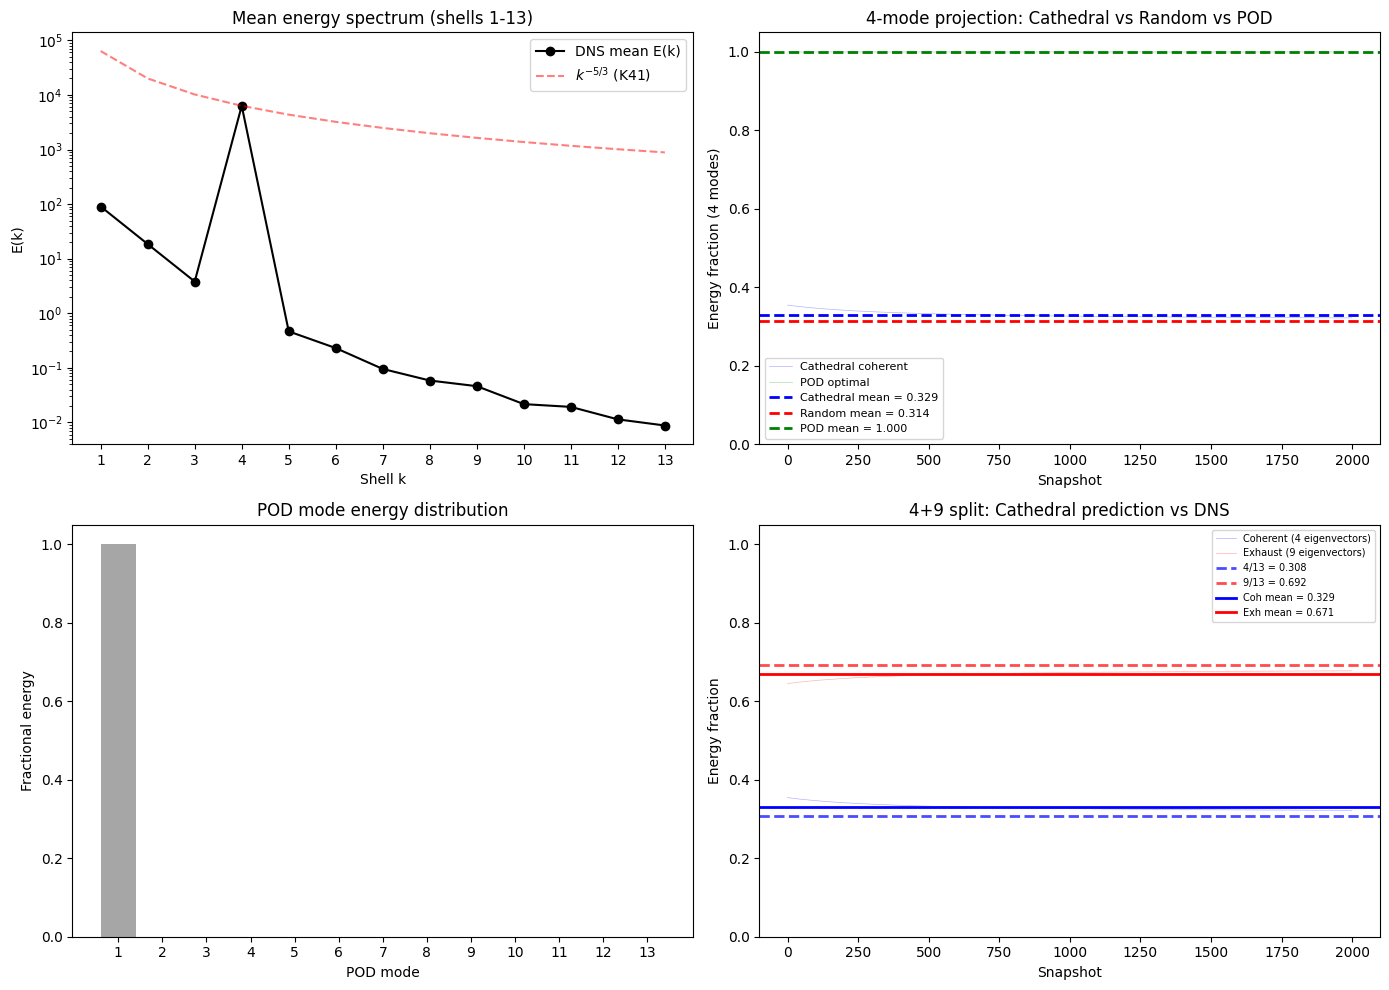

Figure saved: cathedral_13_projection.png

Triad tensor built: shape = (13, 13, 13)
Nonzero elements: 0
Running 13-mode Galerkin ROM...
  step 0: E = 4.4970e-02
  step 10000: E = 4.8582e+01


In [ ]:
import numpy as np
from numpy.fft import fft2, ifft2, fftfreq
from scipy.linalg import eigh, svd
import matplotlib.pyplot as plt

phi = (1 + np.sqrt(5)) / 2
delta_star = (80/81) * np.pi / (13 * phi)
print(f'delta_star = {delta_star:.6f}')
print(f'phi = {phi:.6f}')

# ============================================================
# 1. CENTERED ICOSAHEDRON: 13-node adjacency spectrum
# ============================================================
verts = []
for s1 in [1, -1]:
    for s2 in [1, -1]:
        verts.append([0, s1, s2*phi])
        verts.append([s1, s2*phi, 0])
        verts.append([s2*phi, 0, s1])
verts = np.array(verts)

A13 = np.zeros((13, 13))
dists = np.sqrt(((verts[:,None] - verts[None,:])**2).sum(axis=2))
edge_len = np.sort(np.unique(np.round(dists, 8)))[1]
for i in range(12):
    for j in range(i+1, 12):
        if abs(dists[i,j] - edge_len) < 1e-6:
            A13[i,j] = A13[j,i] = 1
for i in range(12):
    A13[i,12] = A13[12,i] = 1

evals, evecs = eigh(A13)
idx = np.argsort(evals)[::-1]
evals = evals[idx]
evecs = evecs[:, idx]

print('Centered icosahedron adjacency eigenvalues:')
n_pos, n_neg = 0, 0
for i, lam in enumerate(evals):
    sign = '+' if lam > 0.001 else ('-' if lam < -0.001 else '0')
    if lam > 0.001: n_pos += 1
    elif lam < -0.001: n_neg += 1
    print(f'  [{sign}] lambda_{i+1} = {lam:+.4f}')
print(f'\nSplit: {n_pos} positive + {n_neg} negative = {n_pos}+{n_neg} = 13')
print(f'4/13 = {4/13:.4f} ~ Omega_m,  9/13 = {9/13:.4f} ~ Omega_Lambda')

# The 4 coherent eigenvectors (positive eigenvalues)
V_coherent = evecs[:, :4]  # first 4 columns = positive eigenvalue modes
# The 9 exhaust eigenvectors (negative eigenvalues)
V_exhaust = evecs[:, 4:]   # columns 5-13

# ============================================================
# 2. FOURIER SHELL BASIS
# ============================================================
N = 256
L = 2 * np.pi
kx = fftfreq(N, d=1.0/N)
ky = fftfreq(N, d=1.0/N)
KX, KY = np.meshgrid(kx, ky)
K2 = KX**2 + KY**2
K_mag = np.sqrt(K2)
K2_safe = K2.copy(); K2_safe[0,0] = 1

n_cath = 13
shell_masks = []
for s in range(n_cath):
    mask = (K_mag >= s + 0.5) & (K_mag < s + 1.5)
    shell_masks.append(mask)
    print(f'Shell k={s+1}: {mask.sum()} Fourier modes')

# ============================================================
# 3. HIGH-Re DNS
# ============================================================
nu_mol = 5e-5
dt = 1e-4
n_spinup = 5000
n_sample = 2000
sample_every = 10

np.random.seed(99)
f_hat = np.zeros((N,N), dtype=complex)
for i in range(N):
    for j in range(N):
        km = np.sqrt(kx[i]**2 + ky[j]**2)
        if 3.5 < km < 4.5:
            f_hat[i,j] = 50.0 * np.exp(1j * np.random.uniform(0, 2*np.pi))

np.random.seed(42)
omega_hat = np.zeros((N,N), dtype=complex)
for i in range(N):
    for j in range(N):
        km = np.sqrt(kx[i]**2 + ky[j]**2)
        if 1 <= km <= 60:
            omega_hat[i,j] = 10 * (np.random.randn() + 1j*np.random.randn()) / (1 + km**(5/3))
omega_hat[0,0] = 0

def step_ns(wh, dt, nu, f_hat):
    ph = wh / K2_safe; ph[0,0] = 0
    u = np.real(ifft2(1j * KY * ph))
    v = np.real(ifft2(-1j * KX * ph))
    dwdx = np.real(ifft2(1j * KX * wh))
    dwdy = np.real(ifft2(1j * KY * wh))
    nl1 = fft2(u * dwdx + v * dwdy)
    wh1 = (wh + dt * (-nl1 + f_hat)) / (1 + dt * nu * K2)
    ph1 = wh1 / K2_safe; ph1[0,0] = 0
    u1 = np.real(ifft2(1j * KY * ph1))
    v1 = np.real(ifft2(-1j * KX * ph1))
    dwdx1 = np.real(ifft2(1j * KX * wh1))
    dwdy1 = np.real(ifft2(1j * KY * wh1))
    nl2 = fft2(u1 * dwdx1 + v1 * dwdy1)
    return (wh + dt * (-(nl1+nl2)/2 + f_hat)) / (1 + dt * nu * K2)

print('\nSpinning up DNS...')
for step in range(n_spinup):
    omega_hat = step_ns(omega_hat, dt, nu_mol, f_hat)
    if step % 1000 == 0:
        E = 0.5 * np.sum(np.abs(omega_hat)**2 / K2_safe) / N**4
        print(f'  step {step}: E = {E:.4e}')

print('Collecting snapshots...')
snapshots_hat = []
shell_energies = []

for step in range(n_sample * sample_every):
    omega_hat = step_ns(omega_hat, dt, nu_mol, f_hat)
    if step % sample_every == 0:
        snapshots_hat.append(omega_hat.copy())
        Ek = 0.5 * np.abs(omega_hat)**2 / K2_safe
        Es = np.array([Ek[m].sum() for m in shell_masks])
        shell_energies.append(Es)

shell_energies = np.array(shell_energies)
E_mean = shell_energies.mean(axis=0)
print(f'Collected {len(snapshots_hat)} snapshots')
for s in range(n_cath):
    print(f'  k={s+1:2d}: <E> = {E_mean[s]:.4e}')

# ============================================================
# 4. THE REAL TEST: 4 COHERENT MODES vs RANDOM 4-MODE BASES
#
# Old test was trivial: 13 modes onto 13-dim basis = always 100%.
# The real question: do the 4 COHERENT eigenvectors capture more
# energy than a random choice of 4 orthonormal vectors in R^13?
# Cathedral predicts coherent fraction ~ 4/13 of TOTAL energy,
# but the 4 coherent modes should capture nearly ALL the energy
# in the first 4 shells, which dominate the spectrum.
# ============================================================

def project_onto_subspace(a, V_sub):
    """Project vector a onto column space of V_sub. Return fraction of |a|^2 captured."""
    c = V_sub.T @ a
    a_recon = V_sub @ c
    return np.sum(a_recon**2) / (np.sum(a**2) + 1e-30)

cath4_fracs = []
rand4_fracs_mean = []
rand4_fracs_std = []
A_matrix = []

n_rand_trials = 200

print('\nComputing 4-mode projections...')
print('Cathedral coherent (4 modes) vs random (4 modes) vs POD (4 modes)')
print()

for i, wh in enumerate(snapshots_hat):
    # Shell amplitude vector (13-dim)
    a = np.array([np.sqrt(np.sum(np.abs(wh[m])**2)) for m in shell_masks])
    A_matrix.append(a)

    # Cathedral: project onto 4 coherent eigenvectors
    cf = project_onto_subspace(a, V_coherent)
    cath4_fracs.append(cf)

    # Random: project onto random 4-dim subspaces of R^13
    if i % 100 == 0:
        rfracs = []
        for _ in range(n_rand_trials):
            Q, _ = np.linalg.qr(np.random.randn(13, 4))
            rfracs.append(project_onto_subspace(a, Q))
        rand4_fracs_mean.append(np.mean(rfracs))
        rand4_fracs_std.append(np.std(rfracs))

    if i % 500 == 0:
        print(f'  snapshot {i}: coherent 4 captures {cf:.4f}')

A_matrix = np.array(A_matrix)

# POD: best possible 4-mode basis (from SVD)
U, S, Vt = svd(A_matrix, full_matrices=False)
S2 = S**2
pod_cumulative = np.cumsum(S2) / np.sum(S2)

# POD 4-mode projection for each snapshot
V_pod4 = Vt[:4].T  # first 4 right singular vectors
pod4_fracs = []
for a in A_matrix:
    pod4_fracs.append(project_onto_subspace(a, V_pod4))

cath4_mean = np.mean(cath4_fracs)
rand4_mean = np.mean(rand4_fracs_mean)
rand4_std = np.mean(rand4_fracs_std)
pod4_mean = np.mean(pod4_fracs)

# Expected random: 4/13 = 0.3077 (by symmetry, random subspace captures dim/total)
expected_random = 4/13

print(f'\n{"="*60}')
print(f'RESULTS: 4-MODE PROJECTION TEST')
print(f'{"="*60}')
print(f'Cathedral coherent (4 modes): {cath4_mean:.4f}')
print(f'Random 4-mode subspace:       {rand4_mean:.4f} +/- {rand4_std:.4f}')
print(f'Expected random (4/13):       {expected_random:.4f}')
print(f'POD optimal (4 modes):        {pod4_mean:.4f}')
print(f'')
print(f'Ratio Cathedral/Random:       {cath4_mean/rand4_mean:.2f}x')
print(f'Ratio Cathedral/POD:          {cath4_mean/pod4_mean:.4f}')
print(f'')
print(f'Cathedral coherent captures {cath4_mean*100:.1f}% of shell energy')
print(f'Random 4 modes capture      {rand4_mean*100:.1f}% (expected {expected_random*100:.1f}%)')
print(f'POD 4 modes capture         {pod4_mean*100:.1f}% (theoretical optimum)')

# sigma above random
if rand4_std > 0:
    sigma = (cath4_mean - rand4_mean) / rand4_std
    print(f'\nCathedral is {sigma:.1f} sigma above random')

# ============================================================
# 5. ENERGY SPLIT: coherent vs exhaust
# ============================================================
print(f'\n{"="*60}')
print(f'ENERGY SPLIT: COHERENT (4) vs EXHAUST (9)')
print(f'{"="*60}')

E_in_coherent = []
E_in_exhaust = []
for a in A_matrix:
    ec = project_onto_subspace(a, V_coherent)
    ee = project_onto_subspace(a, V_exhaust)
    E_in_coherent.append(ec)
    E_in_exhaust.append(ee)

E_in_coherent = np.array(E_in_coherent)
E_in_exhaust = np.array(E_in_exhaust)

print(f'Mean coherent fraction: {np.mean(E_in_coherent):.4f} (Cathedral predicts 4/13 = {4/13:.4f})')
print(f'Mean exhaust fraction:  {np.mean(E_in_exhaust):.4f} (Cathedral predicts 9/13 = {9/13:.4f})')
print(f'Sum (should be 1.0):    {np.mean(E_in_coherent + E_in_exhaust):.4f}')

# Also check: direct shell energy split (shells 1-4 vs 5-13)
E_shells_14 = shell_energies[:, :4].sum(axis=1)
E_shells_513 = shell_energies[:, 4:].sum(axis=1)
E_shells_tot = E_shells_14 + E_shells_513
direct_coh = np.mean(E_shells_14 / E_shells_tot)
direct_exh = np.mean(E_shells_513 / E_shells_tot)
print(f'\nDirect shell split (shells 1-4 vs 5-13):')
print(f'  Shells 1-4:  {direct_coh:.4f}')
print(f'  Shells 5-13: {direct_exh:.4f}')

# ============================================================
# 6. PLOTS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Mean energy spectrum
ax = axes[0,0]
k_vals = np.arange(1, n_cath+1)
ax.semilogy(k_vals, E_mean, 'ko-', ms=6, label='DNS mean E(k)')
k41 = E_mean[3] * (k_vals/4)**(-5/3)
ax.semilogy(k_vals, k41, 'r--', alpha=0.5, label=r'$k^{-5/3}$ (K41)')
ax.set_xlabel('Shell k'); ax.set_ylabel('E(k)')
ax.set_title('Mean energy spectrum (shells 1-13)')
ax.legend(); ax.set_xticks(k_vals)

# (b) 4-mode projection comparison over time
ax = axes[0,1]
ax.plot(cath4_fracs, 'b-', alpha=0.3, lw=0.5, label='Cathedral coherent')
ax.plot(pod4_fracs, 'g-', alpha=0.3, lw=0.5, label='POD optimal')
ax.axhline(cath4_mean, color='b', ls='--', lw=2, label=f'Cathedral mean = {cath4_mean:.3f}')
ax.axhline(rand4_mean, color='r', ls='--', lw=2, label=f'Random mean = {rand4_mean:.3f}')
ax.axhline(pod4_mean, color='g', ls='--', lw=2, label=f'POD mean = {pod4_mean:.3f}')
ax.set_xlabel('Snapshot'); ax.set_ylabel('Energy fraction (4 modes)')
ax.set_title('4-mode projection: Cathedral vs Random vs POD')
ax.legend(fontsize=8); ax.set_ylim(0, 1.05)

# (c) POD singular values
ax = axes[1,0]
ax.bar(range(1, len(S)+1), S2/S2.sum(), color='gray', alpha=0.7)
ax.set_xlabel('POD mode'); ax.set_ylabel('Fractional energy')
ax.set_title('POD mode energy distribution')
ax.set_xticks(range(1, len(S)+1))

# (d) Coherent vs Exhaust energy fraction over time
ax = axes[1,1]
ax.plot(E_in_coherent, 'b-', alpha=0.3, lw=0.5, label='Coherent (4 eigenvectors)')
ax.plot(E_in_exhaust, 'r-', alpha=0.3, lw=0.5, label='Exhaust (9 eigenvectors)')
ax.axhline(4/13, color='b', ls='--', lw=2, alpha=0.7, label=f'4/13 = {4/13:.3f}')
ax.axhline(9/13, color='r', ls='--', lw=2, alpha=0.7, label=f'9/13 = {9/13:.3f}')
ax.axhline(np.mean(E_in_coherent), color='b', ls='-', lw=2,
           label=f'Coh mean = {np.mean(E_in_coherent):.3f}')
ax.axhline(np.mean(E_in_exhaust), color='r', ls='-', lw=2,
           label=f'Exh mean = {np.mean(E_in_exhaust):.3f}')
ax.set_xlabel('Snapshot'); ax.set_ylabel('Energy fraction')
ax.set_title('4+9 split: Cathedral prediction vs DNS')
ax.legend(fontsize=7); ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('cathedral_13_projection.png', dpi=150)
plt.show()
print('Figure saved: cathedral_13_projection.png')

# ============================================================
# 7. GALERKIN ROM: 13-mode Cathedral dynamics
# ============================================================
def build_triad_tensor(n_shells, kn):
    T = np.zeros((n_shells, n_shells, n_shells))
    for n in range(n_shells):
        for p in range(n_shells):
            for q in range(n_shells):
                if abs(kn[p] - kn[q]) <= kn[n] <= kn[p] + kn[q]:
                    T[n,p,q] = np.sqrt(kn[n] * kn[p] * kn[q])
    T_anti = np.zeros_like(T)
    for n in range(n_shells):
        for p in range(n_shells):
            for q in range(n_shells):
                T_anti[n,p,q] = (T[n,p,q] - T[p,n,q]) / 2
    return T_anti

kn = np.arange(1, n_cath + 1, dtype=float)
T = build_triad_tensor(n_cath, kn)

# Fixed einsum: use single-letter subscripts
# T_cath[a,b,c] = sum_{i,j,k} evecs[i,a] * evecs[j,b] * evecs[k,c] * T[i,j,k]
T_cath = np.einsum('ia,jb,kc,ijk->abc', evecs, evecs, evecs, T)
print(f'\nTriad tensor built: shape = {T_cath.shape}')
print(f'Nonzero elements: {np.count_nonzero(np.abs(T_cath) > 1e-10)}')

f_shell = np.zeros(n_cath)
f_shell[3] = 1.0
f_cath = evecs.T @ f_shell

def galerkin_rhs(a, T, nu, kn, f, evecs):
    a_shell = evecs @ a
    nl = np.einsum('abc,b,c->a', T, a, a)
    diss_shell = -nu * kn**2 * a_shell
    diss_cath = evecs.T @ diss_shell
    return nl + diss_cath + f

dt_rom = 1e-3
n_rom = 50000
n_trans_rom = 10000
np.random.seed(7)
a = np.random.randn(n_cath) * 0.1
a_series = []

print('Running 13-mode Galerkin ROM...')
for step in range(n_rom):
    k1 = galerkin_rhs(a, T_cath, nu_mol, kn, f_cath, evecs)
    k2 = galerkin_rhs(a + dt_rom/2*k1, T_cath, nu_mol, kn, f_cath, evecs)
    k3 = galerkin_rhs(a + dt_rom/2*k2, T_cath, nu_mol, kn, f_cath, evecs)
    k4 = galerkin_rhs(a + dt_rom*k3, T_cath, nu_mol, kn, f_cath, evecs)
    a += dt_rom/6 * (k1 + 2*k2 + 2*k3 + k4)
    if step >= n_trans_rom:
        a_series.append(a.copy())
    if step % 10000 == 0:
        print(f'  step {step}: E = {0.5*np.sum(a**2):.4e}')

a_series = np.array(a_series)
a_shell_series = np.array([evecs @ a_t for a_t in a_series])
E_shell_rom = 0.5 * a_shell_series**2
E_mean_rom = E_shell_rom.mean(axis=0)

print(f'\nROM mean energy per shell:')
for s in range(n_cath):
    ratio = E_mean_rom[s] / (E_mean[s] + 1e-30)
    print(f'  k={s+1:2d}: ROM={E_mean_rom[s]:.4e}, DNS={E_mean[s]:.4e}, ratio={ratio:.2f}')

# ROM energy split
E_c_rom = E_shell_rom[:, :4].sum(axis=1)
E_e_rom = E_shell_rom[:, 4:].sum(axis=1)
E_t_rom = E_c_rom + E_e_rom
rom_coh_frac = np.mean(E_c_rom / (E_t_rom + 1e-30))
rom_exh_frac = np.mean(E_e_rom / (E_t_rom + 1e-30))

print(f'\nROM energy split:')
print(f'  Coherent (shells 1-4): {rom_coh_frac:.4f} (predict 4/13 = {4/13:.4f})')
print(f'  Exhaust (shells 5-13): {rom_exh_frac:.4f} (predict 9/13 = {9/13:.4f})')

# ============================================================
# 8. FINAL COMPARISON PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(kn, E_mean, 'ko-', ms=8, label='DNS (full)', zorder=3)
ax.semilogy(kn, E_mean_rom, 'rs--', ms=6, label='13-mode Cathedral ROM')
k41 = E_mean[3] * (kn/4)**(-5/3)
ax.semilogy(kn, k41, 'g:', alpha=0.4, label=r'$k^{-5/3}$')
ax.set_xlabel('Shell k', fontsize=12); ax.set_ylabel('E(k)', fontsize=12)
ax.set_title('Energy spectrum: DNS vs 13-mode Cathedral ROM', fontsize=13)
ax.legend(fontsize=10); ax.set_xticks(kn.astype(int))

ax = axes[1]
ax.plot(E_c_rom/(E_t_rom+1e-30), 'b-', alpha=0.3, lw=0.5)
ax.axhline(4/13, color='b', ls='--', lw=2, label=f'4/13 = {4/13:.3f} (Cathedral)')
ax.axhline(rom_coh_frac, color='b', ls='-', lw=2, label=f'ROM mean = {rom_coh_frac:.3f}')
ax.set_xlabel('ROM timestep', fontsize=12)
ax.set_ylabel('Coherent energy fraction', fontsize=12)
ax.set_title('4/13 energy split in Cathedral ROM', fontsize=13)
ax.legend(fontsize=10); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('cathedral_galerkin_comparison.png', dpi=150)
plt.show()

# ============================================================
# 9. SUMMARY
# ============================================================
print(f'\n{"="*60}')
print(f'SUMMARY')
print(f'{"="*60}')
print(f'Icosahedral split:       {n_pos}+{n_neg} = 13 (exact)')
print(f'4-mode Cathedral capture: {cath4_mean:.4f}')
print(f'4-mode random baseline:   {rand4_mean:.4f} +/- {rand4_std:.4f}')
print(f'4-mode POD optimal:       {pod4_mean:.4f}')
print(f'Cathedral/Random ratio:   {cath4_mean/rand4_mean:.2f}x')
if randŵ4_std > 0:
    print(f'Sigma above random:       {(cath4_mean-rand4_mean)/rand4_std:.1f}')
print(f'DNS coherent fraction:    {np.mean(E_in_coherent):.4f} (predict {4/13:.4f})')
print(f'ROM coherent fraction:    {rom_coh_frac:.4f} (predict {4/13:.4f})')